# Análises de Negócio — Mercado Financeiro e Criptomoedas

Este notebook responde às perguntas de negócio do MVP de Engenharia de Dados utilizando as tabelas analíticas da camada Gold.

O estudo considera o período de janeiro de 2021 a dezembro de 2025, com retornos mensais comparáveis de fevereiro de 2021 a dezembro de 2025.

As análises utilizam PySpark e SQL para investigar desempenho, volatilidade, risco-retorno, retorno real, correlações e cenários de mercado.

Os resultados são retrospectivos e não constituem recomendação de investimento. Correlações são interpretadas como associações estatísticas, sem inferência de causalidade.

In [0]:
from pyspark.sql import functions as F

catalogo = spark.sql(
    "SELECT current_catalog() AS catalogo"
).collect()[0]["catalogo"]

def nome_tabela(schema, tabela):
    return f"`{catalogo}`.`{schema}`.`{tabela}`"

tabelas = {
    "mercado": "mercado_mensal",
    "macro": "macro_mensal",
    "analise": "analise_mensal",
    "desempenho": "desempenho_ativos",
    "volatilidade": "volatilidade_anual",
    "correlacoes": "correlacoes",
    "cenarios": "cenarios_mensais",
    "desempenho_cenarios": "desempenho_cenarios",
    "evolucao": "evolucao_acumulada"
}

for view, tabela in tabelas.items():
    spark.table(
        nome_tabela("gold", tabela)
    ).createOrReplaceTempView(view)

print("Tabelas Gold carregadas para análise.")
print("Catálogo:", catalogo)

Tabelas Gold carregadas para análise.
Catálogo: workspace


## 1. Qual foi a criptomoeda com melhor desempenho?

A análise compara o retorno acumulado e o retorno anualizado das quatro criptomoedas no intervalo comum de fevereiro de 2021 a dezembro de 2025.

São apresentadas duas perspectivas: retorno original em USDT e retorno aproximado em reais. A perspectiva em reais utiliza a PTAX USD/BRL e assume paridade entre USDT e USD.

O retorno acumulado considera a composição dos retornos mensais, sem aportes adicionais, custos de negociação ou impostos.

In [0]:
ranking_criptos = spark.sql("""
SELECT
    a.ativo,
    ROUND(
        (EXP(SUM(LOG(1 + a.retorno_mensal))) - 1) * 100,
        2
    ) AS retorno_acumulado_usdt_pct,
    ROUND(
        d.retorno_acumulado * 100,
        2
    ) AS retorno_acumulado_brl_pct,
    ROUND(
        d.retorno_anualizado * 100,
        2
    ) AS retorno_anualizado_brl_pct,
    d.meses_com_retorno
FROM analise a
JOIN desempenho d
    ON a.ativo = d.ativo
WHERE a.classe_ativo = 'CRIPTO'
  AND a.retorno_mensal IS NOT NULL
GROUP BY
    a.ativo,
    d.retorno_acumulado,
    d.retorno_anualizado,
    d.meses_com_retorno
ORDER BY retorno_acumulado_brl_pct DESC
""")

display(ranking_criptos)

ativo,retorno_acumulado_usdt_pct,retorno_acumulado_brl_pct,retorno_anualizado_brl_pct,meses_com_retorno
SOLUSDT,2831.22,2845.4,98.98,59
XRPUSDT,272.13,273.93,30.77,59
BTCUSDT,164.85,166.14,22.03,59
ETHUSDT,126.4,127.5,18.2,59


### Resposta

No período analisado, a Solana apresentou o melhor desempenho entre as criptomoedas, com retorno acumulado aproximado em reais de 2.845,4%.

Apesar do resultado expressivo, esse desempenho deve ser analisado em conjunto com as medidas de risco, já que a Solana também apresentou níveis elevados de volatilidade e drawdown ao longo do período.

## 2. Como as criptomoedas se comparam ao Ibovespa?

A comparação utiliza os retornos mensais aproximados em reais para as criptomoedas e os retornos do índice Ibovespa.

A análise considera retorno acumulado, retorno anualizado e volatilidade anualizada. O Ibovespa é um índice de mercado, e seu retorno por pontos não inclui necessariamente a experiência de um investimento real com custos, taxas ou características específicas de um produto financeiro.

A conversão de criptomoedas para reais é aproximada e não considera desvios de paridade do USDT.

In [0]:
comparacao_ativos = spark.sql("""
SELECT
    ativo,
    classe_ativo,
    meses_com_retorno,
    ROUND(retorno_acumulado * 100, 2)
        AS retorno_acumulado_pct,
    ROUND(retorno_anualizado * 100, 2)
        AS retorno_anualizado_pct,
    ROUND(volatilidade_anualizada * 100, 2)
        AS volatilidade_anualizada_pct,
    ROUND(drawdown_maximo * 100, 2)
        AS drawdown_maximo_pct
FROM desempenho
ORDER BY retorno_acumulado_pct DESC
""")

display(comparacao_ativos)

ativo,classe_ativo,meses_com_retorno,retorno_acumulado_pct,retorno_anualizado_pct,volatilidade_anualizada_pct,drawdown_maximo_pct
SOLUSDT,CRIPTO,59,2845.4,98.98,175.63,-95.56
XRPUSDT,CRIPTO,59,273.93,30.77,171.53,-80.36
BTCUSDT,CRIPTO,59,166.14,22.03,61.72,-75.05
ETHUSDT,CRIPTO,59,127.5,18.2,78.12,-78.44
IBOV,INDICE,59,40.03,7.09,16.82,-22.29


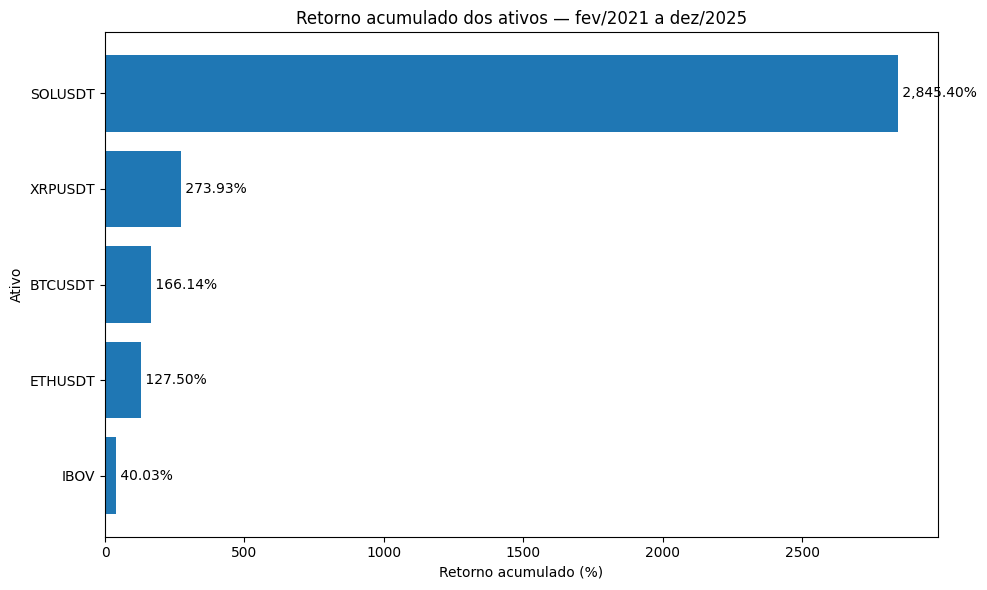

In [0]:
import matplotlib.pyplot as plt

df_plot = comparacao_ativos.toPandas()

df_plot = df_plot.sort_values(
    by="retorno_acumulado_pct",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    df_plot["ativo"],
    df_plot["retorno_acumulado_pct"]
)

plt.xlabel("Retorno acumulado (%)")
plt.ylabel("Ativo")
plt.title("Retorno acumulado dos ativos — fev/2021 a dez/2025")

for i, valor in enumerate(df_plot["retorno_acumulado_pct"]):
    plt.text(
        valor,
        i,
        f" {valor:,.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [0]:
evolucao_comparativa = spark.sql("""
SELECT
    mes_referencia,
    ativo,
    ROUND(indice_nominal * 100, 2)
        AS indice_base_100
FROM evolucao
ORDER BY mes_referencia, ativo
""")

display(evolucao_comparativa)

mes_referencia,ativo,indice_base_100
2021-02-01,BTCUSDT,137.74
2021-02-01,ETHUSDT,109.2
2021-02-01,IBOV,95.63
2021-02-01,SOLUSDT,310.84
2021-02-01,XRPUSDT,84.79
2021-03-01,BTCUSDT,184.68
2021-03-01,ETHUSDT,152.14
2021-03-01,IBOV,101.36
2021-03-01,SOLUSDT,474.31
2021-03-01,XRPUSDT,119.75


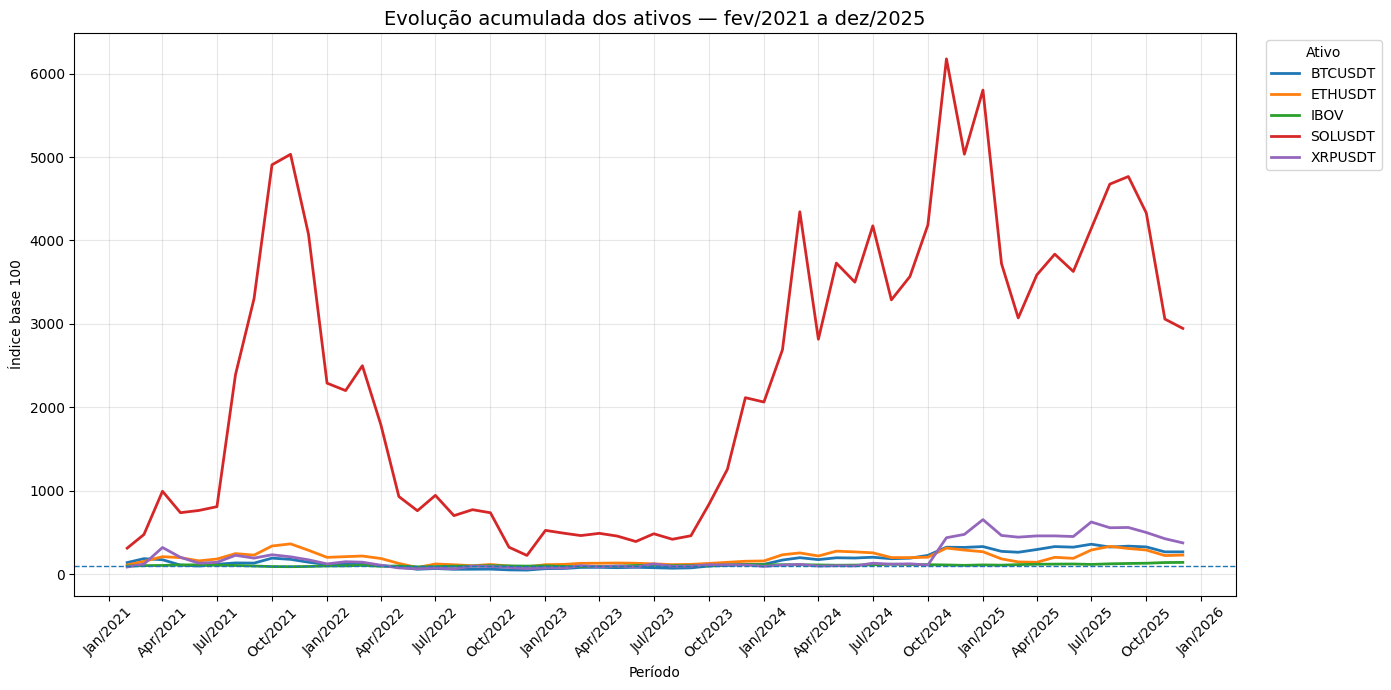

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Converter o DataFrame Spark para Pandas
df_evolucao_plot = evolucao_comparativa.toPandas()

# Garantir que a data esteja no formato correto
df_evolucao_plot["mes_referencia"] = pd.to_datetime(
    df_evolucao_plot["mes_referencia"]
)

# Ordenar os dados
df_evolucao_plot = df_evolucao_plot.sort_values(
    ["mes_referencia", "ativo"]
)

# Criar o gráfico
plt.figure(figsize=(14, 7))

for ativo in df_evolucao_plot["ativo"].unique():

    dados_ativo = df_evolucao_plot[
        df_evolucao_plot["ativo"] == ativo
    ]

    plt.plot(
        dados_ativo["mes_referencia"],
        dados_ativo["indice_base_100"],
        label=ativo,
        linewidth=2
    )

# Títulos e eixos
plt.title(
    "Evolução acumulada dos ativos — fev/2021 a dez/2025",
    fontsize=14
)

plt.xlabel("Período")
plt.ylabel("Índice base 100")

# Formatação das datas
plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b/%Y")
)

plt.xticks(rotation=45)

# Linha de referência da base 100
plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1
)

plt.legend(
    title="Ativo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Resposta

No intervalo comparável, todas as criptomoedas analisadas apresentaram retorno acumulado superior ao Ibovespa. O índice acumulou aproximadamente 40,03%, enquanto os criptoativos registraram retornos mais elevados, com destaque para a Solana.

Por outro lado, o Ibovespa apresentou volatilidade e drawdown significativamente menores, indicando um comportamento mais estável quando comparado às criptomoedas analisadas.

## 3. Quais ativos apresentaram maior volatilidade?

A volatilidade anualizada é utilizada como medida de dispersão dos retornos mensais.

Valores mais elevados indicam maior variabilidade histórica, mas não representam isoladamente todo o risco de um investimento. Também são considerados o drawdown e a distribuição dos retornos.

A comparação é feita em uma mesma frequência mensal, evitando anualizações incompatíveis entre criptomoedas e Ibovespa.

In [0]:
ranking_volatilidade = spark.sql("""
SELECT
    ativo,
    ROUND(volatilidade_anualizada * 100, 2)
        AS volatilidade_anualizada_pct,
    ROUND(drawdown_maximo * 100, 2)
        AS drawdown_maximo_pct,
    ROUND(retorno_medio_mensal * 100, 2)
        AS retorno_medio_mensal_pct
FROM desempenho
ORDER BY volatilidade_anualizada_pct DESC
""")

display(ranking_volatilidade)

ativo,volatilidade_anualizada_pct,drawdown_maximo_pct,retorno_medio_mensal_pct
SOLUSDT,175.63,-95.56,14.22
XRPUSDT,171.53,-80.36,8.37
ETHUSDT,78.12,-78.44,3.71
BTCUSDT,61.72,-75.05,3.15
IBOV,16.82,-22.29,0.69


In [0]:
volatilidade_por_ano = spark.sql("""
SELECT
    ano,
    ativo,
    meses_com_retorno,
    ROUND(volatilidade_anualizada * 100, 2)
        AS volatilidade_anualizada_pct,
    ROUND(retorno_acumulado_ano * 100, 2)
        AS retorno_acumulado_ano_pct
FROM volatilidade
ORDER BY ano, ativo
""")

display(volatilidade_por_ano)

ano,ativo,meses_com_retorno,volatilidade_anualizada_pct,retorno_acumulado_ano_pct
2021,BTCUSDT,11,90.45,42.33
2021,ETHUSDT,11,85.38,185.43
2021,IBOV,11,15.93,-8.9
2021,SOLUSDT,11,284.01,3973.77
2021,XRPUSDT,11,202.98,70.79
2022,BTCUSDT,12,46.01,-66.53
2022,ETHUSDT,12,86.77,-69.58
2022,IBOV,12,21.72,4.69
2022,SOLUSDT,12,89.25,-94.52
2022,XRPUSDT,12,83.28,-61.81


### Resposta

A Solana apresentou a maior volatilidade anualizada no período, com aproximadamente 175,63%, seguida pelo XRP, com cerca de 171,53%.

Bitcoin e Ethereum apresentaram níveis intermediários de volatilidade, enquanto o Ibovespa registrou aproximadamente 16,82%, sendo o ativo com menor dispersão dos retornos entre os analisados.

Esse resultado evidencia a diferença de perfil de risco entre o mercado tradicional e os criptoativos, principalmente quando observamos também os níveis de drawdown.


## 4. Qual ativo apresentou a melhor relação risco-retorno?

A relação risco-retorno é avaliada dividindo o retorno anualizado composto pela volatilidade anualizada.

O indicador é descritivo e não corresponde ao índice de Sharpe, pois não desconta uma taxa livre de risco. Valores negativos indicam retorno anualizado negativo, e a métrica deve ser interpretada em conjunto com o retorno acumulado e o drawdown.

A análise também utiliza uma visualização de dispersão para comparar retorno e volatilidade dos cinco ativos.

In [0]:
risco_retorno = spark.sql("""
SELECT
    ativo,
    ROUND(retorno_anualizado * 100, 2)
        AS retorno_anualizado_pct,
    ROUND(volatilidade_anualizada * 100, 2)
        AS volatilidade_anualizada_pct,
    ROUND(relacao_retorno_volatilidade, 4)
        AS relacao_retorno_volatilidade,
    ROUND(drawdown_maximo * 100, 2)
        AS drawdown_maximo_pct
FROM desempenho
ORDER BY relacao_retorno_volatilidade DESC
""")

display(risco_retorno)

ativo,retorno_anualizado_pct,volatilidade_anualizada_pct,relacao_retorno_volatilidade,drawdown_maximo_pct
SOLUSDT,98.98,175.63,0.5636,-95.56
IBOV,7.09,16.82,0.4215,-22.29
BTCUSDT,22.03,61.72,0.3569,-75.05
ETHUSDT,18.2,78.12,0.2329,-78.44
XRPUSDT,30.77,171.53,0.1794,-80.36


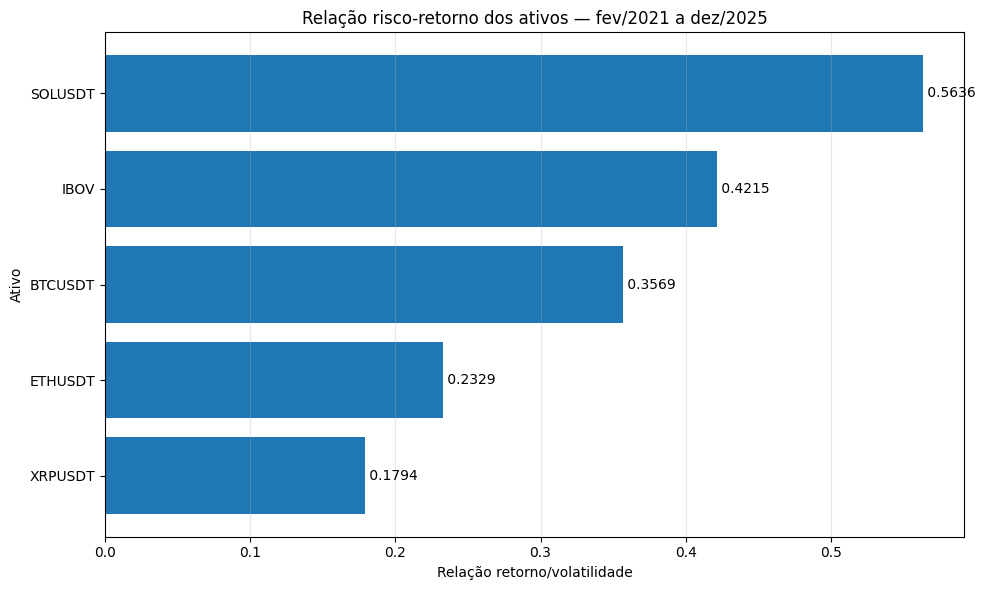

In [0]:
import matplotlib.pyplot as plt

df_risco_retorno_plot = risco_retorno.toPandas()

df_risco_retorno_plot = df_risco_retorno_plot.sort_values(
    by="relacao_retorno_volatilidade",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    df_risco_retorno_plot["ativo"],
    df_risco_retorno_plot["relacao_retorno_volatilidade"]
)

plt.xlabel("Relação retorno/volatilidade")
plt.ylabel("Ativo")
plt.title("Relação risco-retorno dos ativos — fev/2021 a dez/2025")

for i, valor in enumerate(
    df_risco_retorno_plot["relacao_retorno_volatilidade"]
):
    plt.text(
        valor,
        i,
        f" {valor:.4f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Resposta

A Solana apresentou a melhor relação entre retorno anualizado e volatilidade, com valor aproximado de 0,5636.

O Ibovespa apareceu na segunda posição, com aproximadamente 0,4215, mesmo apresentando retorno absoluto bem inferior ao da Solana. Isso mostra que um ativo pode ter menor retorno, mas ainda apresentar uma relação relativamente favorável entre desempenho e volatilidade.

Essa métrica é utilizada apenas como indicador descritivo e não corresponde ao índice de Sharpe, pois não considera uma taxa livre de risco.

## 5. Quais ativos obtiveram retorno real positivo após o IPCA?

O retorno real é calculado pela composição dos retornos mensais em reais, descontando o fator de inflação de cada mês.

A análise identifica quais ativos apresentaram retorno real acumulado positivo e compara o resultado nominal com o resultado ajustado pelo IPCA.

Para criptomoedas, o retorno em reais é uma aproximação baseada na paridade USDT/USD e na PTAX. O cálculo não considera custos, impostos ou diferenças entre a inflação pessoal do investidor e o IPCA.

In [0]:
retorno_real = spark.sql("""
SELECT
    ativo,
    ROUND(retorno_acumulado * 100, 2)
        AS retorno_nominal_acumulado_pct,
    ROUND(retorno_real_acumulado * 100, 2)
        AS retorno_real_acumulado_pct,
    CASE
        WHEN retorno_real_acumulado > 0
            THEN 'POSITIVO'
        WHEN retorno_real_acumulado < 0
            THEN 'NEGATIVO'
        ELSE 'NEUTRO'
    END AS classificacao_real
FROM desempenho
ORDER BY retorno_real_acumulado_pct DESC
""")

display(retorno_real)

ativo,retorno_nominal_acumulado_pct,retorno_real_acumulado_pct,classificacao_real
SOLUSDT,2845.4,2117.82,POSITIVO
XRPUSDT,273.93,181.56,POSITIVO
BTCUSDT,166.14,100.39,POSITIVO
ETHUSDT,127.5,71.3,POSITIVO
IBOV,40.03,5.44,POSITIVO


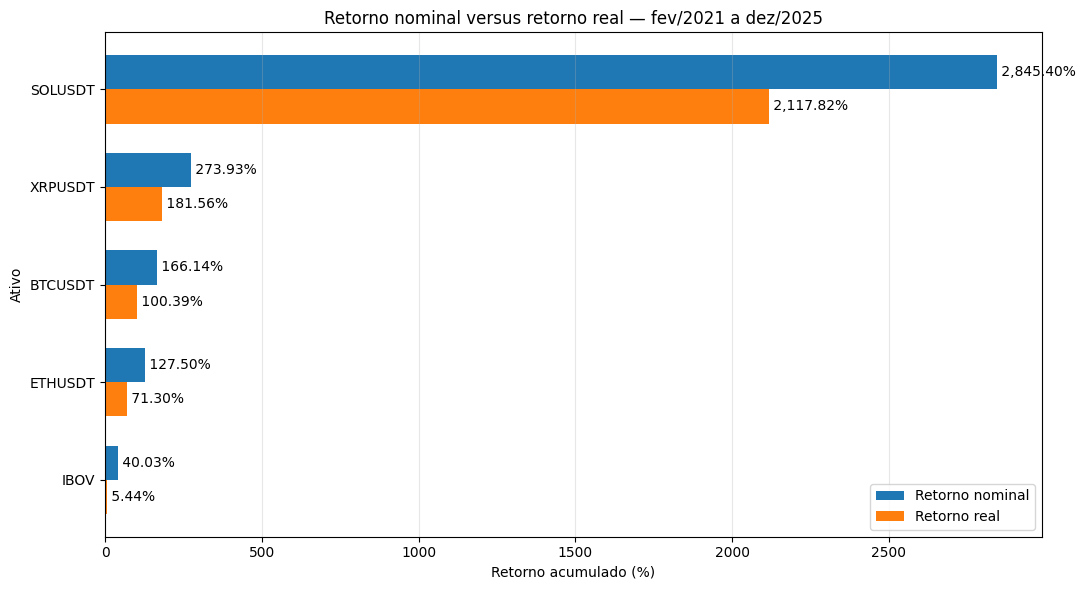

In [0]:
import matplotlib.pyplot as plt
import numpy as np

df_retorno_real_plot = retorno_real.toPandas()

df_retorno_real_plot = df_retorno_real_plot.sort_values(
    by="retorno_nominal_acumulado_pct",
    ascending=True
)

y = np.arange(len(df_retorno_real_plot))
altura = 0.35

plt.figure(figsize=(11, 6))

plt.barh(
    y + altura / 2,
    df_retorno_real_plot["retorno_nominal_acumulado_pct"],
    height=altura,
    label="Retorno nominal"
)

plt.barh(
    y - altura / 2,
    df_retorno_real_plot["retorno_real_acumulado_pct"],
    height=altura,
    label="Retorno real"
)

plt.yticks(
    y,
    df_retorno_real_plot["ativo"]
)

plt.xlabel("Retorno acumulado (%)")
plt.ylabel("Ativo")
plt.title("Retorno nominal versus retorno real — fev/2021 a dez/2025")

for i, valor in enumerate(
    df_retorno_real_plot["retorno_nominal_acumulado_pct"]
):
    plt.text(
        valor,
        i + altura / 2,
        f" {valor:,.2f}%",
        va="center"
    )

for i, valor in enumerate(
    df_retorno_real_plot["retorno_real_acumulado_pct"]
):
    plt.text(
        valor,
        i - altura / 2,
        f" {valor:,.2f}%",
        va="center"
    )

plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Resposta

Todos os cinco ativos analisados apresentaram retorno real acumulado positivo no período comparável.

A inflação acumulada, medida pelo IPCA entre fevereiro de 2021 e dezembro de 2025, foi de aproximadamente 32,81%. Mesmo após esse ajuste, a Solana permaneceu com o maior retorno real acumulado, seguida por XRP, Bitcoin e Ethereum.

O Ibovespa também apresentou retorno real positivo, porém próximo de 5,44%, valor significativamente inferior ao observado para as criptomoedas.


In [0]:
inflacao_periodo = spark.sql("""
SELECT
    MIN(mes_referencia) AS primeiro_mes,
    MAX(mes_referencia) AS ultimo_mes,
    COUNT(*) AS meses,
    ROUND(
        (EXP(SUM(LOG(fator_inflacao))) - 1) * 100,
        2
    ) AS ipca_acumulado_pct
FROM macro
WHERE mes_referencia BETWEEN DATE '2021-02-01'
                         AND DATE '2025-12-01'
""")

display(inflacao_periodo)

primeiro_mes,ultimo_mes,meses,ipca_acumulado_pct
2021-02-01,2025-12-01,59,32.81


## 6. Qual é a relação entre Bitcoin e Ibovespa?

A associação linear entre Bitcoin e Ibovespa é avaliada por meio da correlação de Pearson dos retornos mensais alinhados.

São comparadas duas perspectivas: BTC em USDT versus Ibovespa e BTC aproximado em reais versus Ibovespa.

A comparação permite observar se o componente cambial altera a associação. Correlação não indica causalidade, nem garante que a relação permaneça estável em outros períodos.

In [0]:
correlacao_btc_ibov = spark.sql("""
SELECT
    perspectiva,
    variavel_a,
    variavel_b,
    observacoes,
    ROUND(correlacao_pearson, 4)
        AS correlacao_pearson
FROM correlacoes
WHERE
    (
        variavel_a IN ('BTCUSDT', 'BTCUSDT_ORIGINAL')
        AND variavel_b IN ('IBOV', 'IBOV_ORIGINAL')
    )
ORDER BY perspectiva
""")

display(correlacao_btc_ibov)

perspectiva,variavel_a,variavel_b,observacoes,correlacao_pearson
RETORNO_BRL,BTCUSDT,IBOV,59,-0.1255
RETORNO_ORIGINAL,BTCUSDT_ORIGINAL,IBOV_ORIGINAL,59,-0.0118


In [0]:
btc_ibov_mensal = spark.sql("""
SELECT
    b.mes_referencia,
    ROUND(b.retorno_brl * 100, 4)
        AS retorno_btc_brl_pct,
    ROUND(i.retorno_brl * 100, 4)
        AS retorno_ibov_pct
FROM analise b
JOIN analise i
    ON b.mes_referencia = i.mes_referencia
WHERE b.ativo = 'BTCUSDT'
  AND i.ativo = 'IBOV'
  AND b.retorno_brl IS NOT NULL
  AND i.retorno_brl IS NOT NULL
ORDER BY b.mes_referencia
""")

display(btc_ibov_mensal)

mes_referencia,retorno_btc_brl_pct,retorno_ibov_pct
2021-02-01,37.7429,-4.3734
2021-03-01,34.0746,5.9968
2021-04-01,-6.8444,1.9378
2021-05-01,-37.4771,6.1583
2021-06-01,-10.0643,0.4642
2021-07-01,21.1343,-3.9439
2021-08-01,14.0819,-2.4793
2021-09-01,-1.6005,-6.5683
2021-10-01,45.1126,-6.7386
2021-11-01,-7.4753,-1.5316


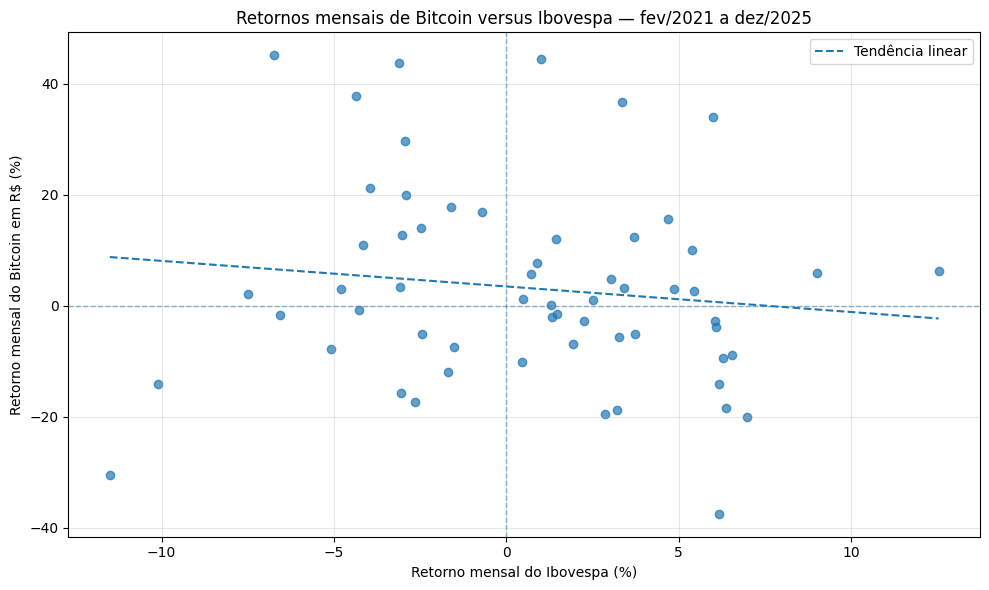

In [0]:
import matplotlib.pyplot as plt
import numpy as np

df_btc_ibov_plot = btc_ibov_mensal.toPandas()

# Remover eventuais valores nulos
df_btc_ibov_plot = df_btc_ibov_plot.dropna(
    subset=["retorno_ibov_pct", "retorno_btc_brl_pct"]
)

x = df_btc_ibov_plot["retorno_ibov_pct"]
y = df_btc_ibov_plot["retorno_btc_brl_pct"]

plt.figure(figsize=(10, 6))

# Pontos observados
plt.scatter(
    x,
    y,
    alpha=0.7
)

# Linha de tendência linear
coeficientes = np.polyfit(x, y, 1)
linha_tendencia = np.poly1d(coeficientes)

x_linha = np.linspace(x.min(), x.max(), 100)

plt.plot(
    x_linha,
    linha_tendencia(x_linha),
    linestyle="--",
    linewidth=1.5,
    label="Tendência linear"
)

# Linhas de referência
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    alpha=0.5
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1,
    alpha=0.5
)

plt.xlabel("Retorno mensal do Ibovespa (%)")
plt.ylabel("Retorno mensal do Bitcoin em R$ (%)")

plt.title(
    "Retornos mensais de Bitcoin versus Ibovespa — fev/2021 a dez/2025"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Resposta

A correlação entre os retornos mensais do Bitcoin e do Ibovespa foi fraca durante o período analisado.

Na perspectiva aproximada em reais, a correlação de Pearson foi de aproximadamente -0,1255. Já na perspectiva dos retornos originais, o valor ficou ainda mais próximo de zero.

Dessa forma, os resultados não indicam uma associação linear forte entre os dois ativos no período estudado. Esse resultado não significa independência entre os mercados e também não permite estabelecer relações de causa e efeito.

## 7. Como os retornos se associam à Selic e ao dólar?

A análise explora a correlação dos retornos mensais dos ativos com três variáveis: variação mensal do dólar, nível da Meta Selic ao final do mês e variação da Meta Selic em pontos percentuais.

A Meta Selic é uma taxa anual definida pelo Copom. Seu nível não é tratado como retorno mensal de investimento.

As correlações são contemporâneas e retrospectivas. Não são utilizadas para afirmar que mudanças na Selic ou no dólar causaram os retornos observados.

In [0]:
correlacoes_macro = spark.sql("""
SELECT
    perspectiva,
    variavel_a AS ativo,
    variavel_b AS indicador,
    observacoes,
    ROUND(correlacao_pearson, 4)
        AS correlacao_pearson
FROM correlacoes
WHERE variavel_b IN (
    'variacao_dolar_mensal',
    'selic_meta_pct_aa',
    'variacao_selic_pp'
)
ORDER BY perspectiva, indicador, ativo
""")

display(correlacoes_macro)

perspectiva,ativo,indicador,observacoes,correlacao_pearson
RETORNO_BRL,BTCUSDT,selic_meta_pct_aa,59,-0.1467
RETORNO_BRL,ETHUSDT,selic_meta_pct_aa,59,-0.1813
RETORNO_BRL,IBOV,selic_meta_pct_aa,59,0.1301
RETORNO_BRL,SOLUSDT,selic_meta_pct_aa,59,-0.4546
RETORNO_BRL,XRPUSDT,selic_meta_pct_aa,59,-0.135
RETORNO_BRL,variacao_dolar_mensal,selic_meta_pct_aa,59,-0.0323
RETORNO_BRL,BTCUSDT,variacao_dolar_mensal,59,0.1343
RETORNO_BRL,ETHUSDT,variacao_dolar_mensal,59,0.0456
RETORNO_BRL,IBOV,variacao_dolar_mensal,59,-0.625
RETORNO_BRL,SOLUSDT,variacao_dolar_mensal,59,-0.0017


In [0]:
evolucao_macro = spark.sql("""
SELECT
    mes_referencia,
    ROUND(usd_brl, 4) AS usd_brl,
    ROUND(selic_meta_pct_aa, 2) AS selic_meta_pct_aa,
    ROUND(variacao_dolar_mensal * 100, 2)
        AS variacao_dolar_pct,
    ROUND(variacao_selic_pp, 2)
        AS variacao_selic_pp,
    ROUND(ipca_pct_mes, 2) AS ipca_pct_mes
FROM macro
ORDER BY mes_referencia
""")

display(evolucao_macro)

mes_referencia,usd_brl,selic_meta_pct_aa,variacao_dolar_pct,variacao_selic_pp,ipca_pct_mes
2021-01-01,5.4759,2.0,null,null,0.25
2021-02-01,5.5302,2.0,0.99,0.0,0.86
2021-03-01,5.6973,2.75,3.02,0.75,0.93
2021-04-01,5.4036,2.75,-5.16,0.0,0.31
2021-05-01,5.2322,3.5,-3.17,0.75,0.83
2021-06-01,5.0022,4.25,-4.4,0.75,0.53
2021-07-01,5.1216,4.25,2.39,0.0,0.96
2021-08-01,5.1433,5.25,0.42,1.0,0.87
2021-09-01,5.4394,6.25,5.76,1.0,1.16
2021-10-01,5.643,7.75,3.74,1.5,1.25


### Resposta

As correlações observadas entre os retornos dos ativos, a Meta Selic e a variação do dólar foram, em sua maioria, fracas ou moderadas e variaram de acordo com o ativo analisado.

Os resultados não indicam um único padrão de associação entre os indicadores macroeconômicos e todos os ativos. Além disso, a conversão das criptomoedas para reais altera parte das correlações, pois incorpora o efeito da variação cambial.

Essas relações devem ser interpretadas como associações históricas do período estudado e não como evidência de causalidade.

## 8. Como os ativos se comportaram em períodos de alta volatilidade?

Os meses são classificados em baixa, média e alta volatilidade de acordo com a volatilidade realizada do Ibovespa.

São comparados os retornos médios, a dispersão dos retornos, a proporção de meses positivos e os extremos observados em cada cenário.

A classificação é relativa ao período estudado e utiliza informações do próprio mês. Portanto, os cenários servem para análise retrospectiva, não para previsão ou identificação antecipada de crises.

In [0]:
analise_cenarios = spark.sql("""
SELECT
    cenario,
    ativo,
    meses,
    ROUND(retorno_medio_mensal * 100, 2)
        AS retorno_medio_mensal_pct,
    ROUND(volatilidade_mensal * 100, 2)
        AS volatilidade_mensal_pct,
    ROUND(proporcao_meses_positivos * 100, 2)
        AS meses_positivos_pct,
    ROUND(pior_retorno_mensal * 100, 2)
        AS pior_retorno_pct,
    ROUND(melhor_retorno_mensal * 100, 2)
        AS melhor_retorno_pct
FROM desempenho_cenarios
ORDER BY cenario, ativo
""")

display(analise_cenarios)

cenario,ativo,meses,retorno_medio_mensal_pct,volatilidade_mensal_pct,meses_positivos_pct,pior_retorno_pct,melhor_retorno_pct
ALTA_VOLATILIDADE,BTCUSDT,19,5.61,20.05,52.63,-19.42,45.11
ALTA_VOLATILIDADE,ETHUSDT,19,2.87,20.11,52.63,-31.53,48.23
ALTA_VOLATILIDADE,IBOV,19,0.43,4.4,57.89,-6.74,6.16
ALTA_VOLATILIDADE,SOLUSDT,19,17.52,63.13,57.89,-56.2,210.84
ALTA_VOLATILIDADE,XRPUSDT,19,-0.78,21.38,36.84,-30.64,52.88
BAIXA_VOLATILIDADE,BTCUSDT,20,1.62,10.17,55.0,-18.33,17.72
BAIXA_VOLATILIDADE,ETHUSDT,20,3.59,21.04,45.0,-22.99,52.75
BAIXA_VOLATILIDADE,IBOV,20,0.52,3.51,60.0,-5.09,6.54
BAIXA_VOLATILIDADE,SOLUSDT,20,10.84,34.81,55.0,-35.18,109.33
BAIXA_VOLATILIDADE,XRPUSDT,20,6.61,41.57,45.0,-35.13,166.12


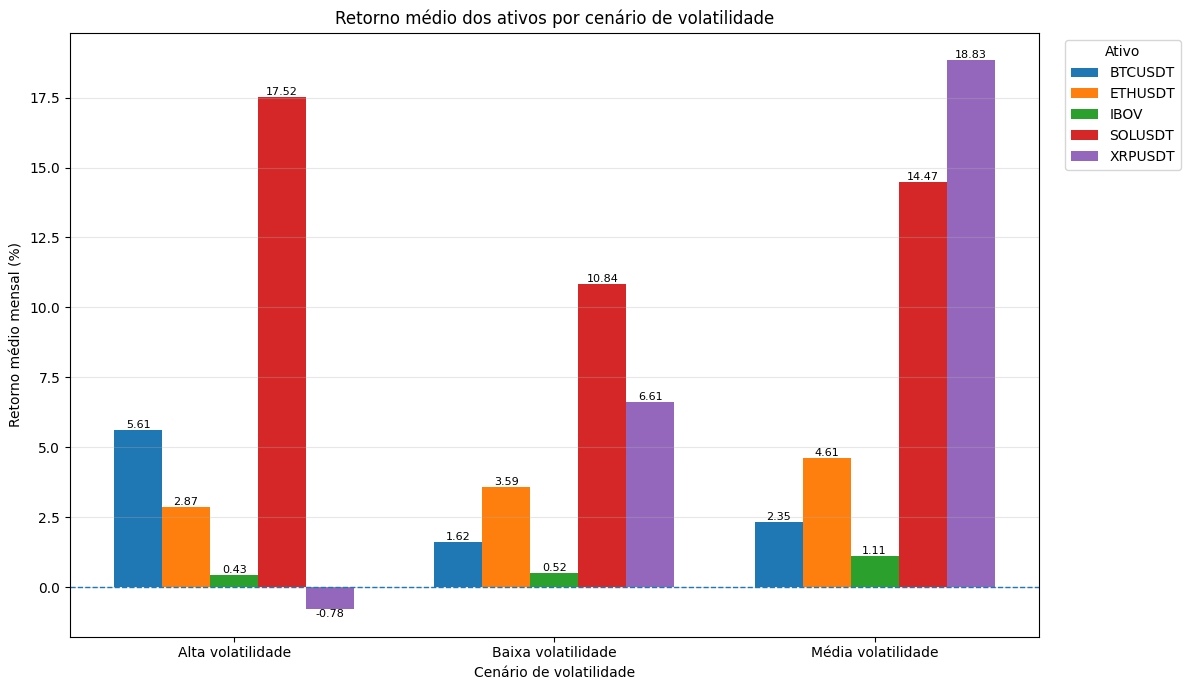

In [0]:
import matplotlib.pyplot as plt
import numpy as np

df_cenarios_plot = analise_cenarios.toPandas()

# Ordem desejada dos cenários
ordem_cenarios = [
    "ALTA_VOLATILIDADE",
    "BAIXA_VOLATILIDADE",
    "MEDIA_VOLATILIDADE"
]

df_cenarios_plot["cenario"] = pd.Categorical(
    df_cenarios_plot["cenario"],
    categories=ordem_cenarios,
    ordered=True
)

df_cenarios_plot = df_cenarios_plot.sort_values(
    by=["cenario", "ativo"]
)

# Criar estrutura para barras agrupadas
cenarios = ordem_cenarios
ativos = sorted(df_cenarios_plot["ativo"].unique())

x = np.arange(len(cenarios))
largura = 0.15

plt.figure(figsize=(12, 7))

for i, ativo in enumerate(ativos):

    dados_ativo = df_cenarios_plot[
        df_cenarios_plot["ativo"] == ativo
    ]

    valores = []

    for cenario in cenarios:
        valor = dados_ativo.loc[
            dados_ativo["cenario"] == cenario,
            "retorno_medio_mensal_pct"
        ]

        if len(valor) > 0:
            valores.append(valor.iloc[0])
        else:
            valores.append(0)

    posicoes = x + (i - (len(ativos) - 1) / 2) * largura

    barras = plt.bar(
        posicoes,
        valores,
        width=largura,
        label=ativo
    )

    for barra, valor in zip(barras, valores):
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height(),
            f"{valor:.2f}",
            ha="center",
            va="bottom" if valor >= 0 else "top",
            fontsize=8
        )

plt.axhline(
    y=0,
    linewidth=1,
    linestyle="--"
)

plt.xticks(
    x,
    ["Alta volatilidade", "Baixa volatilidade", "Média volatilidade"]
)

plt.xlabel("Cenário de volatilidade")
plt.ylabel("Retorno médio mensal (%)")

plt.title(
    "Retorno médio dos ativos por cenário de volatilidade"
)

plt.legend(
    title="Ativo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Resposta

Nos meses classificados como de alta volatilidade do Ibovespa, os criptoativos continuaram apresentando resultados bastante diferentes entre si.

A Solana registrou retorno médio mensal positivo e elevado nesse cenário, enquanto o XRP apresentou retorno médio negativo nos meses de alta volatilidade.

Esse resultado mostra que os criptoativos não reagiram de forma uniforme aos períodos de maior instabilidade do mercado brasileiro.

Como os cenários foram definidos com informações do próprio mês, essa análise é retrospectiva e não deve ser interpretada como mecanismo de previsão.

In [0]:
meses_maior_volatilidade = spark.sql("""
SELECT
    mes_referencia,
    cenario,
    pregoes_com_retorno,
    ROUND(volatilidade_realizada_anualizada * 100, 2)
        AS volatilidade_realizada_pct
FROM cenarios
ORDER BY volatilidade_realizada_anualizada DESC
LIMIT 10
""")

display(meses_maior_volatilidade)

mes_referencia,cenario,pregoes_com_retorno,volatilidade_realizada_pct
2022-10-01,ALTA_VOLATILIDADE,20,29.8
2022-11-01,ALTA_VOLATILIDADE,20,27.72
2021-02-01,ALTA_VOLATILIDADE,18,27.61
2021-09-01,ALTA_VOLATILIDADE,21,26.51
2021-01-01,ALTA_VOLATILIDADE,18,26.31
2021-10-01,ALTA_VOLATILIDADE,20,25.16
2022-09-01,ALTA_VOLATILIDADE,21,23.53
2021-03-01,ALTA_VOLATILIDADE,23,23.4
2021-11-01,ALTA_VOLATILIDADE,20,22.5
2023-01-01,ALTA_VOLATILIDADE,22,22.14


## 9. Quais criptomoedas apresentam comportamento semelhante?

A semelhança entre as criptomoedas é investigada por meio da correlação dos retornos mensais originais em USDT.

Também são comparadas a volatilidade, o retorno acumulado e o drawdown. Uma correlação elevada indica que os retornos tenderam a se mover na mesma direção durante o período, mas não significa que os ativos possuem o mesmo risco ou desempenho.

A análise utiliza somente os pares observados e não constitui uma medida completa de diversificação de portfólio.

In [0]:
correlacoes_criptos = spark.sql("""
SELECT
    REPLACE(variavel_a, '_ORIGINAL', '') AS cripto_a,
    REPLACE(variavel_b, '_ORIGINAL', '') AS cripto_b,
    observacoes,
    ROUND(correlacao_pearson, 4)
        AS correlacao_pearson
FROM correlacoes
WHERE perspectiva = 'RETORNO_ORIGINAL'
  AND variavel_a LIKE '%USDT_ORIGINAL'
  AND variavel_b LIKE '%USDT_ORIGINAL'
ORDER BY correlacao_pearson DESC
""")

display(correlacoes_criptos)

cripto_a,cripto_b,observacoes,correlacao_pearson
BTCUSDT,ETHUSDT,59,0.7434
BTCUSDT,SOLUSDT,59,0.6331
ETHUSDT,SOLUSDT,59,0.5661
ETHUSDT,XRPUSDT,59,0.54
BTCUSDT,XRPUSDT,59,0.4252
SOLUSDT,XRPUSDT,59,0.3809


In [0]:
perfil_criptos = spark.sql("""
SELECT
    ativo,
    ROUND(retorno_acumulado * 100, 2)
        AS retorno_acumulado_pct,
    ROUND(volatilidade_anualizada * 100, 2)
        AS volatilidade_anualizada_pct,
    ROUND(drawdown_maximo * 100, 2)
        AS drawdown_maximo_pct,
    ROUND(relacao_retorno_volatilidade, 4)
        AS relacao_retorno_volatilidade
FROM desempenho
WHERE classe_ativo = 'CRIPTO'
ORDER BY volatilidade_anualizada_pct DESC
""")

display(perfil_criptos)

ativo,retorno_acumulado_pct,volatilidade_anualizada_pct,drawdown_maximo_pct,relacao_retorno_volatilidade
SOLUSDT,2845.4,175.63,-95.56,0.5636
XRPUSDT,273.93,171.53,-80.36,0.1794
ETHUSDT,127.5,78.12,-78.44,0.2329
BTCUSDT,166.14,61.72,-75.05,0.3569


### Resposta

A maior correlação entre as criptomoedas foi observada entre Bitcoin e Ethereum, indicando que os retornos dos dois ativos apresentaram maior tendência de movimentação conjunta durante o período analisado.

Os demais pares também apresentaram correlações positivas, porém com intensidades diferentes. Isso mostra que existe algum grau de comportamento semelhante entre os criptoativos, mas essa relação não é igual para todos os pares.

Mesmo quando dois ativos apresentam retornos correlacionados, isso não significa que possuam o mesmo nível de risco, retorno ou drawdown.


## 10. Quais foram as principais diferenças entre as criptomoedas?

As diferenças são avaliadas em termos de retorno acumulado, volatilidade, drawdown, relação risco-retorno e comportamento nos cenários de mercado.

A análise busca identificar se o ativo de maior retorno também apresentou o maior risco e se as correlações entre criptomoedas permaneceram elevadas apesar das diferenças individuais.

As conclusões consideram exclusivamente o período estudado, sem extrapolar os resultados para o futuro.

In [0]:
sintese_criptos = spark.sql("""
SELECT
    d.ativo,
    ROUND(d.retorno_acumulado * 100, 2)
        AS retorno_acumulado_pct,
    ROUND(d.retorno_real_acumulado * 100, 2)
        AS retorno_real_acumulado_pct,
    ROUND(d.volatilidade_anualizada * 100, 2)
        AS volatilidade_anualizada_pct,
    ROUND(d.drawdown_maximo * 100, 2)
        AS drawdown_maximo_pct,
    ROUND(d.relacao_retorno_volatilidade, 4)
        AS relacao_retorno_volatilidade,
    ROUND(
        MAX(
            CASE
                WHEN c.cenario = 'ALTA_VOLATILIDADE'
                THEN c.retorno_medio_mensal
            END
        ) * 100,
        2
    ) AS retorno_medio_alta_vol_pct
FROM desempenho d
LEFT JOIN desempenho_cenarios c
    ON d.ativo = c.ativo
WHERE d.classe_ativo = 'CRIPTO'
GROUP BY
    d.ativo,
    d.retorno_acumulado,
    d.retorno_real_acumulado,
    d.volatilidade_anualizada,
    d.drawdown_maximo,
    d.relacao_retorno_volatilidade
ORDER BY retorno_acumulado_pct DESC
""")

display(sintese_criptos)

ativo,retorno_acumulado_pct,retorno_real_acumulado_pct,volatilidade_anualizada_pct,drawdown_maximo_pct,relacao_retorno_volatilidade,retorno_medio_alta_vol_pct
SOLUSDT,2845.4,2117.82,175.63,-95.56,0.5636,17.52
XRPUSDT,273.93,181.56,171.53,-80.36,0.1794,-0.78
BTCUSDT,166.14,100.39,61.72,-75.05,0.3569,5.61
ETHUSDT,127.5,71.3,78.12,-78.44,0.2329,2.87


### Resposta

As criptomoedas apresentaram diferenças importantes tanto em desempenho quanto em risco ao longo do período analisado.

A Solana apresentou o maior retorno acumulado, de aproximadamente 2.845,40%, mas também registrou a maior volatilidade anualizada, próxima de 175,63%, além de um drawdown de aproximadamente -95,56%.

O XRP teve o segundo maior retorno acumulado, de cerca de 273,93%, porém também apresentou volatilidade elevada. Bitcoin e Ethereum registraram retornos menores, acompanhados de níveis de volatilidade inferiores aos observados em Solana e XRP.

Esses resultados mostram que o desempenho das criptomoedas não deve ser avaliado apenas pelo retorno acumulado. A análise conjunta de retorno, volatilidade, drawdown e comportamento em diferentes cenários oferece uma visão mais completa das diferenças entre os ativos.

## Síntese dos resultados

De forma geral, os resultados mostram que os criptoativos apresentaram retornos superiores ao Ibovespa no período analisado, mas também estiveram associados a níveis significativamente maiores de volatilidade e drawdown.

A Solana se destacou pelo maior retorno acumulado, enquanto o Ibovespa apresentou o comportamento mais estável entre os ativos avaliados. O ajuste pelo IPCA mostrou que todos os ativos mantiveram retorno real positivo no intervalo comparável.

As correlações analisadas também indicaram que não houve uma relação linear forte entre Bitcoin e Ibovespa, enquanto as criptomoedas apresentaram diferentes níveis de associação entre si.

Esses resultados reforçam a importância de avaliar desempenho e risco de forma conjunta, considerando também inflação, comportamento em diferentes cenários e as limitações metodológicas do estudo.

## Limitações da análise

Os resultados devem ser interpretados considerando algumas limitações metodológicas do projeto.

As criptomoedas foram analisadas em pares USDT e a conversão para reais utiliza a PTAX USD/BRL, assumindo paridade entre USDT e USD. Além disso, o estudo não considera custos de negociação, impostos ou spreads.

As correlações representam associações históricas e não indicam causalidade, enquanto os cenários de volatilidade possuem caráter retrospectivo.

Por fim, os resultados estão restritos ao período analisado e não devem ser interpretados como previsão de desempenho futuro.

## Conclusão do notebook

As dez perguntas de negócio foram investigadas por meio de consultas SQL e indicadores produzidos na camada Gold.

As análises permitem comparar o desempenho e o risco das criptomoedas e do Ibovespa, avaliar retornos reais após o IPCA, explorar associações com dólar e Selic e examinar diferenças entre períodos de volatilidade.

As respostas quantitativas e as visualizações serão utilizadas na documentação final do MVP, juntamente com a discussão crítica, o Data Catalog e a autoavaliação.

O pipeline permanece reproduzível: as fontes são coletadas na Bronze, tratadas na Silver, modeladas na Gold e consultadas nesta etapa analítica.